In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
project_root = os.path.abspath("../..")  # one level up from /notebooks
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
from scipy.signal import fftconvolve
import glob
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.table import Table
from scipy.optimize import curve_fit
from numba import njit
from tqdm import tqdm

from src.class_implementation import NoiseModel, PSFDeconvolver, GAAPPhotometry

In [3]:
@njit
def gaussian_weight(height: int, width: int, xc: float = 0, yc: float = 0, sigmax: float = 1, sigmay: float = 1, normalized=True) -> np.ndarray:
    """
    Calculate Gaussian weight function

    Parameters
    ----------
    height: int
        Height of the weight function in pixels
    width: int
        Width of the weight function in pixels
    xc: float, optional
        x coordinate of the center of the weight function in pixels
    yc: float, optional
        y coordinate of the center of the weight function in pixels
    sigma: float, optional
        Scale parameter of the weight function

    Returns
    -------
    np.ndarray:
        Weight function
    """

    # Create an array for the x and y direction
    x = np.arange(width)
    y = np.arange(height)

    # Calculate the Gaussian in the x and y direction
    gx = np.exp(-0.5 * ((x - xc) / sigmax) ** 2)
    gy = np.exp(-0.5 * ((y - yc) / sigmay) ** 2)

    # Combining the x and y direction to make a 2D Gaussian
    gaussian = gy[:, None] * gx[None, :]
    if normalized:
        return gaussian/np.sum(gaussian)
    return gaussian

In [4]:
plt.rcParams['font.size'] = 16         
plt.rcParams['axes.titlesize'] = 16   
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['image.origin'] = "lower"

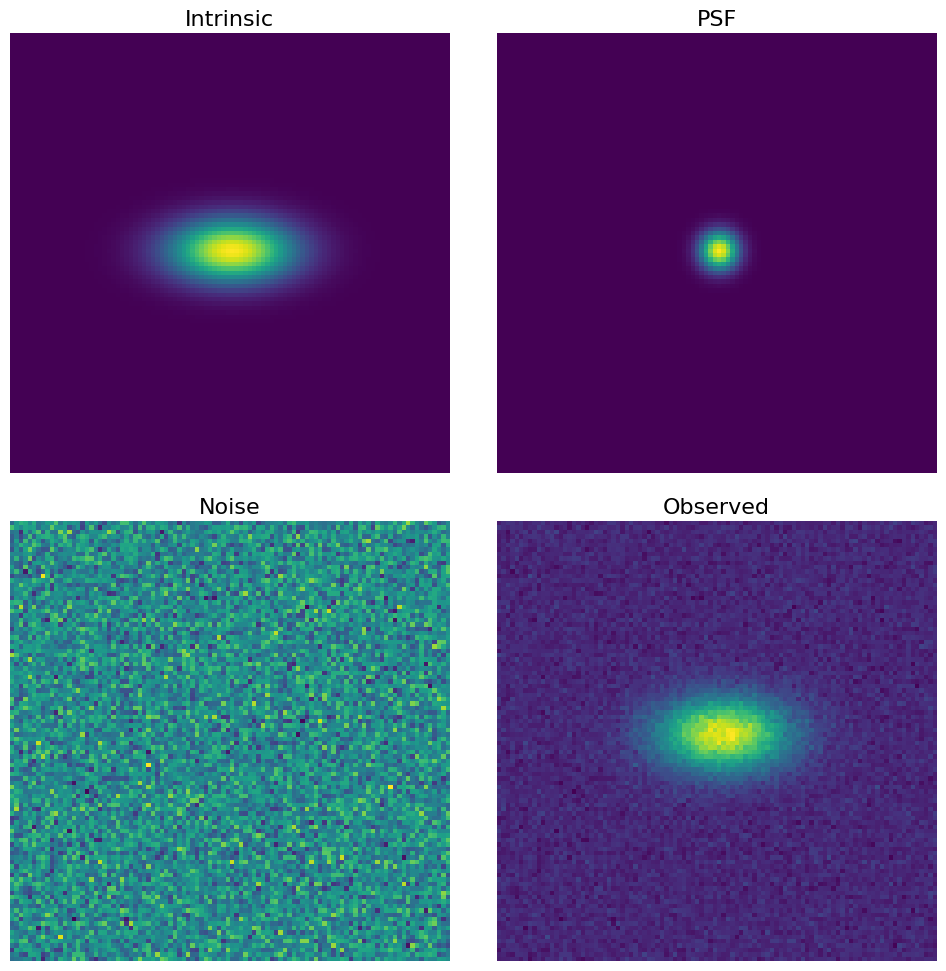

In [5]:
width = 100
height = 100
source_x_sigma = 10
source_y_sigma = 5
# Create PSF and Galaxy images
psf_sigma = 3
image_psf = gaussian_weight(height, width, height / 2, width / 2, psf_sigma, psf_sigma)
image_intrinsic = gaussian_weight(height, width, height / 2, width / 2, source_x_sigma, source_y_sigma) * 1000
# Convolve the galaxy with the PSF
image = fftconvolve(image_intrinsic, image_psf, mode="same")

# Plot
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs[0, 1].imshow(image_psf)
axs[0, 1].set_title("PSF")
axs[0, 1].axis("off")
axs[0, 0].imshow(image_intrinsic, extent=(0, width, 0, height))
axs[0, 0].set_title("Intrinsic")
axs[0, 0].axis("off")
noise_image = np.random.normal(0, .1, (height, width))
axs[1, 0].imshow(noise_image, extent=(0, width, 0, height))
axs[1, 0].set_title("Noise")
axs[1, 0].axis("off")
axs[1, 1].imshow(image + noise_image, extent=(0, width, 0, height))
axs[1, 1].set_title("Observed")
axs[1, 1].axis("off")
plt.tight_layout()
plt.savefig('/home/deklerk/GAAP/results/figures/simulation/fiducial_model.pdf')
plt.show()

In [6]:
# Define weight function
weight = gaussian_weight(height, width, height / 2, width / 2, 8, 8, normalized=False)

size = 100
lag = 0

noise = NoiseModel(np.zeros((height, width), dtype=np.float64))
noise.find_noise_square(size)
noise.create_poisson_image()
noise.set_noise_covariance(lag)
deconv = PSFDeconvolver(image_psf)
deconv.prepare([size, size])

# Calculate the aperture flux using the intrinsic image and weight function
true_F = np.sum(weight * image_intrinsic)
print(f'The aperture flux measured using the intrinsic image and weight function : {true_F:.6f}')
# Calculate the aperture flux using the observed image and rescaled weight function
phot = GAAPPhotometry(
        image=image,
        centers=np.array([np.array([size/2]), np.array([size/2])]),
        sigmas=np.array([8])
    )
phot.measure(size, lag, noise, deconv, show_progress=False)
print(f'The aperture flux using the observed image and rescaled weight function : {phot.flux[0]:.6f}')

The aperture flux measured using the intrinsic image and weight function : 529.740651
The aperture flux using the observed image and rescaled weight function : 529.740648


In [18]:
# size grids
psf_sizes = np.linspace(1e-5, 20, 200)
weight_sizes = np.linspace(1e-5, 20, 400)

ratio = np.zeros((len(weight_sizes), len(psf_sizes)))

# precompute noise once
noise = NoiseModel(noise_image)
noise.find_noise_square(size)
noise.create_poisson_image()
noise.set_noise_covariance(lag)

centers = np.full((2,len(weight_sizes)), size/2)

for j, psf_size in enumerate(tqdm(psf_sizes)):
    psf = gaussian_weight(
        height, width,
        height / 2, width / 2,
        psf_size, psf_size
    )

    deconv = PSFDeconvolver(psf)
    deconv.prepare([size, size])

    blurred = fftconvolve(image_intrinsic, psf, mode="same")
    phot = GAAPPhotometry(
        image=blurred+noise_image,
        centers=centers,
        sigmas=weight_sizes
        )
    phot.measure(size, lag, noise, deconv, show_progress=False)
    for i, weight_size in enumerate(weight_sizes):

        weight = gaussian_weight(
            height, width,
            height / 2, width / 2,
            weight_size, weight_size, normalized=False
        )

        true_F = np.sum(weight * image_intrinsic)

        ratio[i, j] = phot.flux[i] / true_F

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [03:55<00:00,  1.18s/it]


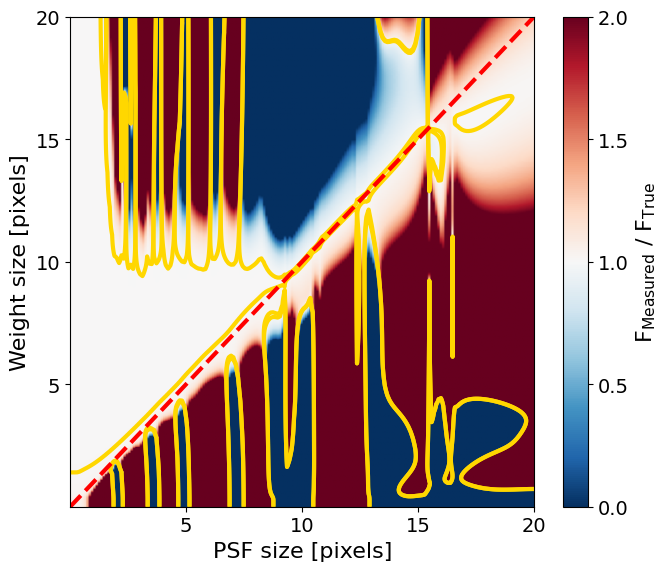

In [19]:
plt.figure(figsize=(7, 6))

im = plt.imshow(
    ratio,
    aspect="auto",
    extent=[
        psf_sizes[0], psf_sizes[-1],
        weight_sizes[0], weight_sizes[-1]
    ],
    vmin=0,
    vmax=2,
    cmap="RdBu_r"
)
ny, nx = ratio.shape
x = np.linspace(psf_sizes[0], psf_sizes[-1], nx)
y = np.linspace(weight_sizes[0], weight_sizes[-1], ny)
X, Y = np.meshgrid(x, y)

plt.colorbar(im, label=r"F$_\mathrm{Measured}$ / F$_\mathrm{True}$", ticks=[0, 0.5, 1, 1.5, 2])
cs = plt.contour(X, Y, ratio, levels=[0.99, 1.01], colors="gold", linewidths=3)
plt.plot([min(psf_sizes), max(psf_sizes)], [min(psf_sizes), max(psf_sizes)], 'r--', linewidth=3)
# plt.clabel(cs, inline=False, fontsize=12, fmt={0.99: "1%", 1.01: "1%"}, inline_spacing=5)
plt.xlabel("PSF size [pixels]")
plt.ylabel("Weight size [pixels]")
plt.yticks(ticks=[5, 10, 15, 20])
plt.tight_layout()
plt.savefig('/home/deklerk/GAAP/results/figures/simulation/flux_weight_psf_size0.pdf')
plt.show()

In [ ]:
psf_sizes = np.arange(0.1, 21, 1)
weight_sizes = np.arange(0.1, 21, 1)
centers = np.full((2,len(weight_sizes)), size/2)
N_trials = 200
lag = 5
result = np.zeros((len(weight_sizes), len(psf_sizes)))
noise = NoiseModel()
flux = np.zeros((N_trials, len(weight_sizes)))
variance = np.zeros((N_trials, len(weight_sizes)))
result = np.zeros((len(psf_sizes), len(weight_sizes)))
for i, psf_size in enumerate(tqdm(psf_sizes)):
    psf = gaussian_weight(
        height, width,
        height / 2, width / 2,
        psf_size, psf_size
    )
    deconv = PSFDeconvolver(psf)
    deconv.prepare([size, size])

    blurred = fftconvolve(image_intrinsic, psf, mode="same")
    noise_images = np.random.normal(0, .1, (N_trials, height, width))
    for k in range(N_trials):
        noise_image = noise_images[k]
        phot = GAAPPhotometry(
                image=blurred+noise_image,
                centers=centers,
                sigmas=weight_sizes
                )
        noise.set_noise_square(noise_image)
        noise.set_noise_covariance(lag)
        phot.measure(size, lag, noise, deconv, show_progress=False)
        
        flux[k] = phot.flux
        variance[k] = phot.variance
    var_flux = np.var(flux, axis=0)
    mean_variance = np.mean(variance, axis=0)
    result[i] = mean_variance / var_flux


  0%|          | 0/21 [00:00<?, ?it/s]

100%|██████████| 21/21 [13:43<00:00, 39.23s/it]


In [33]:
print(np.min(result))

0.7390367576536876


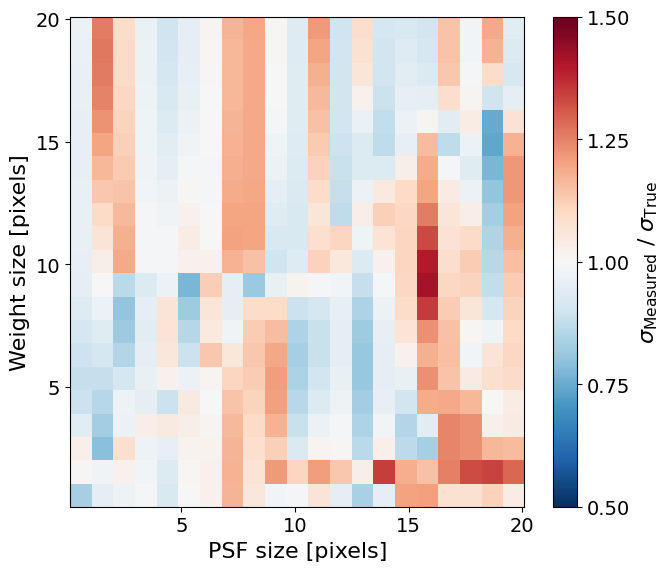

In [35]:
plt.figure(figsize=(7, 6))
plt.imshow(
    result.T,
    extent=[psf_sizes[0], psf_sizes[-1],
            weight_sizes[0], weight_sizes[-1]],
    aspect="auto",
    vmin=0.5,
    vmax=1.5,
    cmap="RdBu_r"
)

plt.colorbar(label=r"$\sigma_\mathrm{Measured}$ / $\sigma_\mathrm{True}$", ticks=[0.5, 0.75, 1, 1.25, 1.5])
plt.xlabel("PSF size [pixels]")
plt.ylabel("Weight size [pixels]")
plt.yticks(ticks=[5, 10, 15, 20])
plt.tight_layout()
plt.savefig('/home/deklerk/GAAP/results/figures/simulation/error_weight_psf_size.pdf')
plt.show()

In [ ]:
weight_size = 8
weights = gaussian_weight(height, width, height / 2, width / 2, weight_size, weight_size)
centers = np.full((2,1), size/2)

image = fftconvolve(image_intrinsic, image_psf, mode="same")
deconv = PSFDeconvolver(image_psf)
deconv.prepare([size, size])

noise_sizes = np.arange(1, 10, 1)
maxlags = np.arange(1, 21, 1)
N_trials = 50

ratio = np.zeros((len(noise_sizes), len(maxlags)))
flux = np.zeros(N_trials)
variance = np.zeros(N_trials)
for i, noise_size in enumerate(tqdm(noise_sizes, disable=False)):
    noise_psf = gaussian_weight(
        height, width,
        height / 2, width / 2,
        noise_size, noise_size
    )
    psf_expanded = noise_psf[None, :, :]  # shape (1, height, width)

    for k, maxlag in enumerate(maxlags):
        noise_images = np.random.normal(0, .1, (N_trials, height, width))
        noise_images = fftconvolve(noise_images, psf_expanded, mode='same')
        for j in range(N_trials):
            noise_image = noise_images[j]
            phot = GAAPPhotometry(
                image=image+noise_image,
                centers=centers,
                sigmas=np.array([weight_size])
                )
            noise.set_noise_square(noise_image)
            noise.set_noise_covariance(maxlag)
            phot.measure(size, maxlag, noise, deconv, show_progress=False)

            flux[j] = phot.flux
            variance[j] = phot.variance
        var_flux = np.var(flux)
        mean_variance = np.mean(variance)
        ratio[i, k] = mean_variance / var_flux

100%|██████████| 9/9 [17:50<00:00, 118.91s/it]


  0%|          | 0/1 [00:00<?, ?it/s]

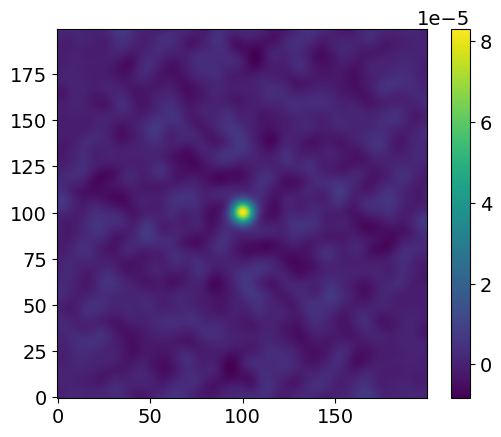

100%|██████████| 1/1 [00:00<00:00,  1.39it/s]

19.69


In [48]:
noise_sizes = np.linspace(1, 9, 10)
noise_sizes = [3]
N_trials = 100
for i, noise_size in enumerate(tqdm(noise_sizes, disable=False)):
    noise_psf = gaussian_weight(
        height, width,
        height / 2, width / 2,
        noise_size, noise_size
    )
    psf_expanded = noise_psf[None, :, :]
    noise_images = np.random.normal(0, .1, (N_trials, 200, 200))
    noise_images = fftconvolve(noise_images, psf_expanded, mode='same')
    maxlag_list = np.zeros(N_trials)
    for j in range(N_trials):
        noise_image = noise_images[j]
        noise.set_noise_square(noise_image)
        noise.set_noise_covariance(49)
        maxlag_list[j] = noise.check_maxlag(0.1)
    plt.imshow(noise.ac)
    plt.colorbar()
    plt.show()
    print(np.mean(maxlag_list))

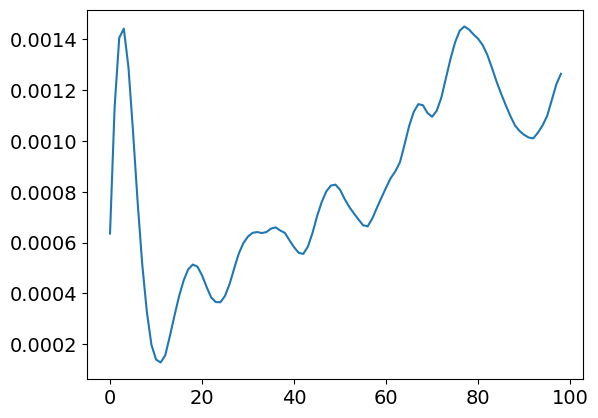

In [64]:
total = np.sum(np.abs(noise.ac))
h, w = noise.ac.shape
cy, cx = h // 2, w // 2
sub_totals = np.zeros(cy)
for i in range(cy):
    sub_total = np.sum(np.abs(noise.ac[cy - i: cy + i + 1,
                                cx - i: cx + i + 1,]))
    sub_totals[i] = sub_total
plt.plot(np.diff(sub_totals))
plt.show()

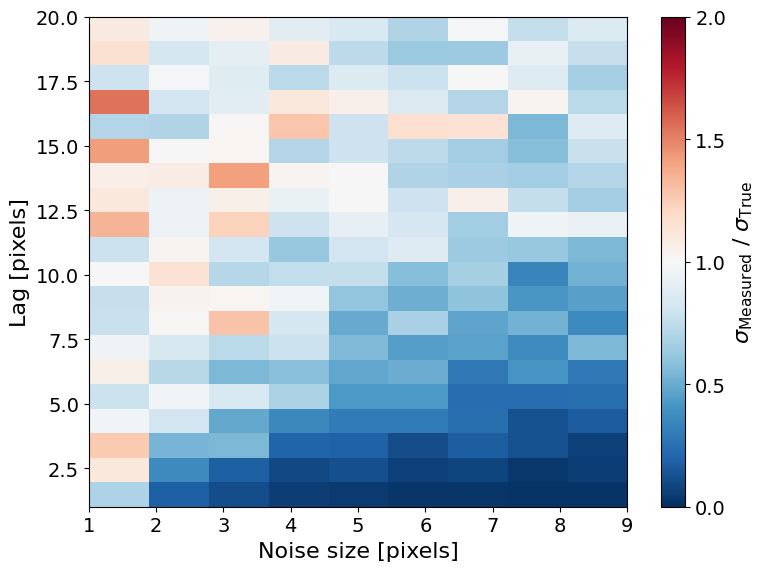

In [27]:
from matplotlib.colors import TwoSlopeNorm
norm = TwoSlopeNorm(vmin=0.0, vcenter=1.0, vmax=2.0)
plt.figure(figsize=(8, 6))
plt.imshow(
    ratio.T,
    origin="lower",
    aspect="auto",
    extent=[noise_sizes[0], noise_sizes[-1], maxlags[0], maxlags[-1]],
    cmap="RdBu_r",
    norm=norm
)
plt.colorbar(label=r"$\sigma_\mathrm{Measured}$ / $\sigma_\mathrm{True}$", ticks=[0, 0.5, 1, 1.5, 2])
# plt.plot(noise_sizes, r_corr)
plt.ylabel("Lag [pixels]")
plt.xlabel("Noise size [pixels]")
plt.ylim(maxlags[0], maxlags[-1])
plt.tight_layout()
plt.savefig('/home/deklerk/GAAP/results/figures/simulation/error_covariance_size.pdf')
plt.show()

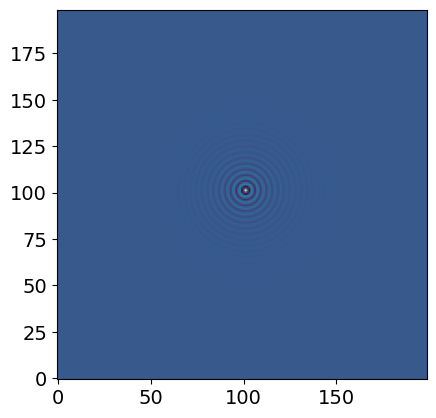

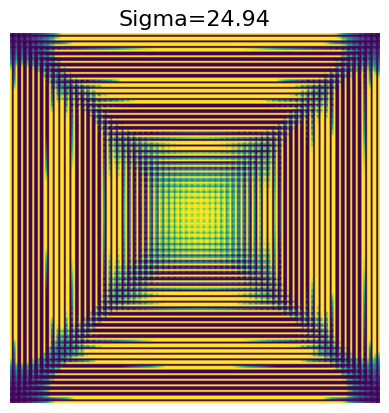

In [114]:
import matplotlib.animation as animation
size = 200

def conversion(x):
    return 50 / (1 + np.exp(-(x/200-5)))

def make_frame(i):
    return deconv.deconvolve(gaussian_weight(
            size, size,
            size / 2, size / 2,
            conversion(i), conversion(i), normalized=False
        ), size)


# First frame
frame = make_frame(1)  # your frame generator
plt.imshow(frame)
plt.show()
fig, ax = plt.subplots()
N_frames = 1000
im = ax.imshow(frame, animated=True, vmin=0, vmax=1)
title = ax.set_title(0)
ax.axis('off')

def update(i):
    frame = make_frame(i)
    im.set_array(frame)

    title.set_text(f"Sigma={conversion(i):.2f}")
    return [im, title]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=N_frames,
    interval=33,   # ~30 fps
    blit=True
)

ani.save("output.mp4", fps=50, dpi=200)

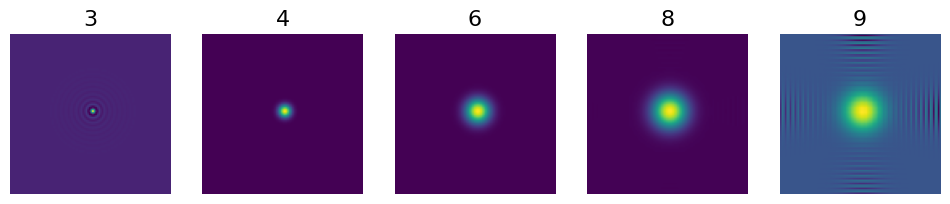

In [77]:
deconv = PSFDeconvolver(image_psf)
weight_sizes = [3, 4, 6, 8, 9]
fig, axs = plt.subplots(1, len(weight_sizes), figsize=(12, 8))
for i, weight_size in enumerate(weight_sizes):
    deconv.prepare([size, size])
    weight = gaussian_weight(
            height, width,
            height / 2, width / 2,
            weight_size, weight_size
        )
    axs[i].imshow(deconv.deconvolve(weight, 100))
    axs[i].set_title(weight_size)
    axs[i].set_axis_off()
plt.show()